# Exercise 05: Boxplot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ab-test.csv')

df.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


## Plotting the Boxplot

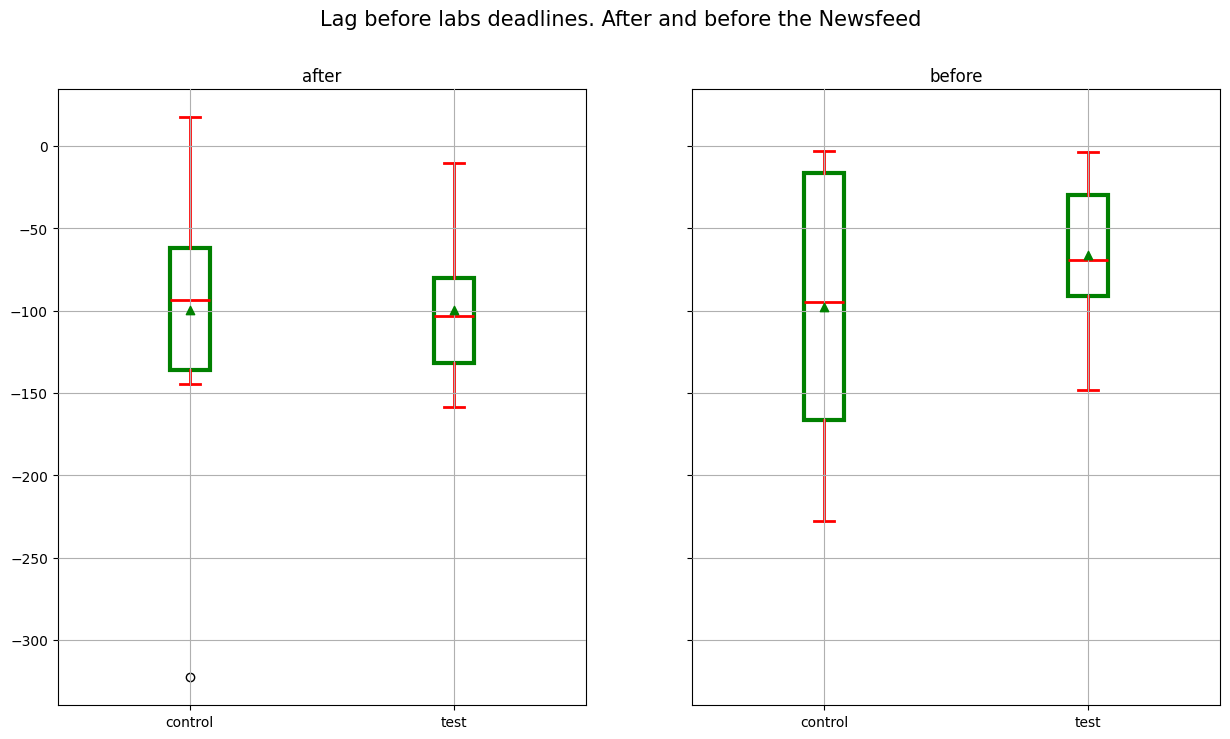

In [ ]:
# split data
before = df[df['time'] == 'before']
after = df[df['time'] == 'after']

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

def plot_box(data, ax, title):
    control = data[data['group'] == 'control']['diff']
    test = data[data['group'] == 'test']['diff']

    bp = ax.boxplot([control, test], patch_artist=True)

    #boxes
    for box in bp['boxes']:
        box.set(edgecolor='green', linewidth=3, facecolor='white')

    #median(red)
    for median in bp['medians']:
        median.set(color='red', linewidth=2)

    #whiskers + caps
    for whisker in bp['whiskers']:
        whisker.set(color='red', linewidth=2)
    for cap in bp['caps']:
        cap.set(color='red', linewidth=2)

    #mean(arrow)
    means = [control.mean(), test.mean()]
    ax.scatter([1, 2], means, color='green', marker='^', zorder=5)

    ax.set_xticklabels(['control', 'test'])
    ax.set_title(title)

plot_box(after, axes[0], 'after')
plot_box(before, axes[1], 'before')

plt.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)

for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_axisbelow(False) #to make it on top
    ax.grid(True)

plt.show()

####  What was the IQR of the control group before the newsfeed? 
####  The answer is approximately 150.

In [3]:
# EXPLANATION, IF NEEDED

# Right plot = before 
# Left box there = control 
# Top of box (Q3) ≈ -20
# Bottom of box (Q1) ≈ -170
# IQR=Q3−Q1=(−20)−(−170)=150